### Analysis

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned_superstore_data.csv')
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit', 'ship_time'],
      dtype='str')

### Question 1 : What are our total sales? 

In [2]:
df["sales"].describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: sales, dtype: float64

In [5]:
df["sales"].sum()

np.float64(2297200.8603)

#### Answer:
##### Our total sales are 2297200.8603 with a mean of 229.858, max value of 22638.48, min value of 0.444 and median of 54.49

### Question 2: How do sales change over time?

In [21]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Group by year and month
df['month'] = df['order_date'].dt.to_period('M')
sales_by_month = df.groupby('month')['sales'].sum()

# Group by year
df['year'] = df['order_date'].dt.year
sales_by_year = df.groupby('year')['sales'].sum()

sales_by_month.head()


month
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: sales, dtype: float64

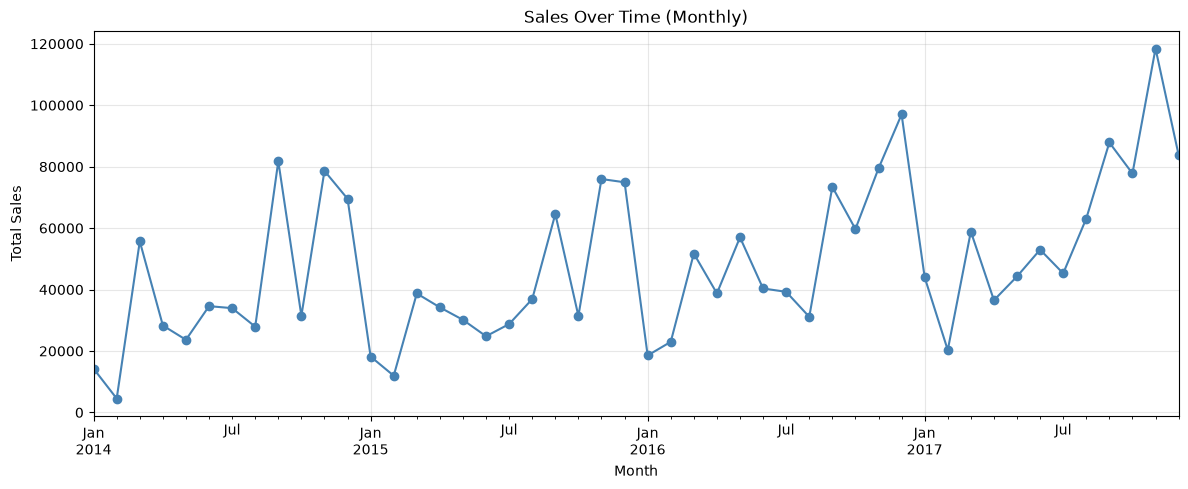

In [17]:
# Create line charts
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Line chart by month
sales_by_month.plot(ax=axes, kind='line', marker='o', color='steelblue')
axes.set_title('Sales Over Time (Monthly)')
axes.set_xlabel('Month')
axes.set_ylabel('Total Sales')
axes.grid(True, alpha=0.3)


##### From chart we can see that the sales are increasing during the last period since 2017 with the highest peak on the November with 118447.8250. We also can see that during these years sales goes up starting from November untill December and on january the sales drop so this is a period of 2 months that sales increase. There is an unusual drop from Dectember 2016 untill February 2017

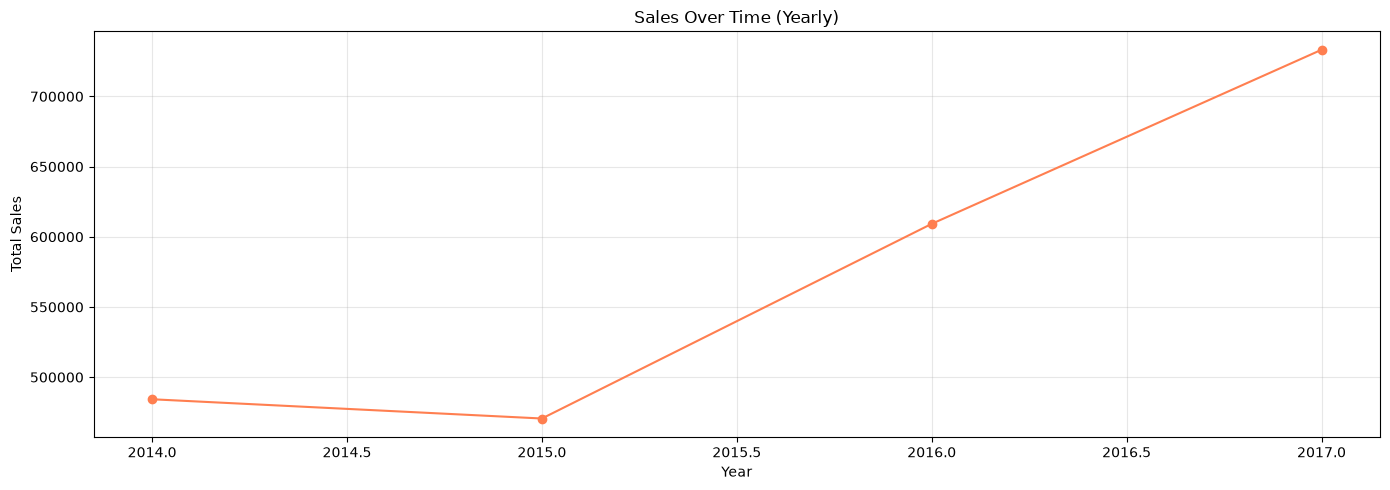

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
# Line chart by year
sales_by_year.plot(ax=axes, kind='line', marker='o', color='coral')
axes.set_title('Sales Over Time (Yearly)')
axes.set_xlabel('Year')
axes.set_ylabel('Total Sales')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### This chart here shows the sales during the years and as we can see here the sales are going up on the last 2 years. We can see a decrease of the sales during the first year but then during 2015-2017 the sales are increasing 

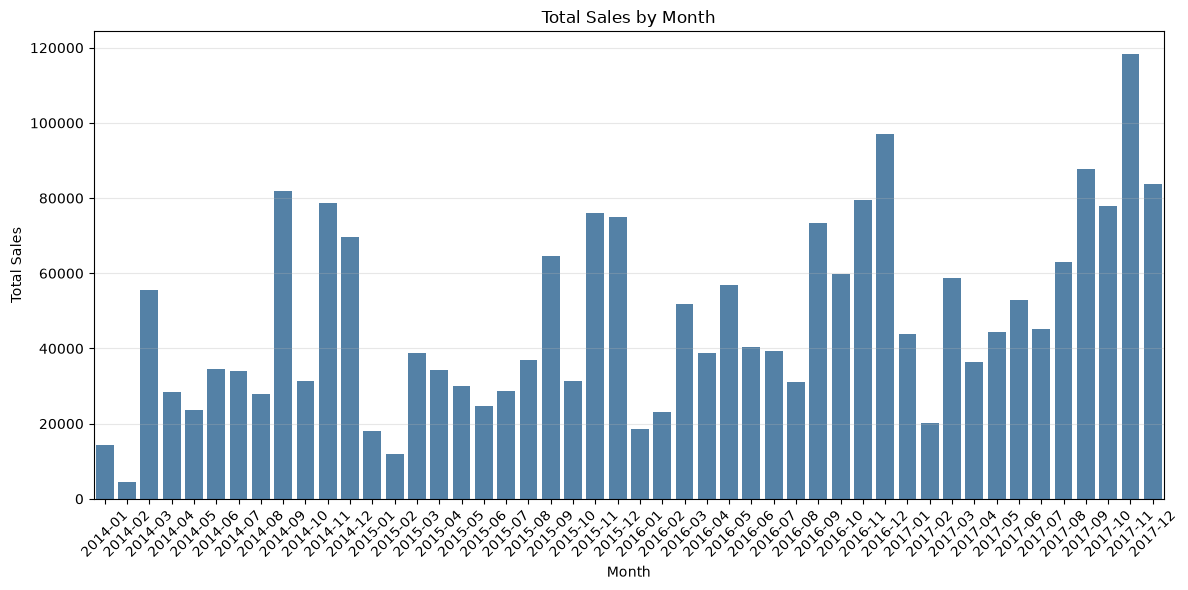

In [75]:
#Bar chart for sales by month
plt.figure(figsize=(12, 6))
plot = sns.barplot(x=sales_by_month.index.astype(str), y=sales_by_month.values, color='steelblue')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Question 3: Which regions generate the most sales?

In [23]:
#sales by region
sales_by_region = df.groupby('region')['sales'].sum().sort_values(ascending=False)
sales_by_region.head()

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

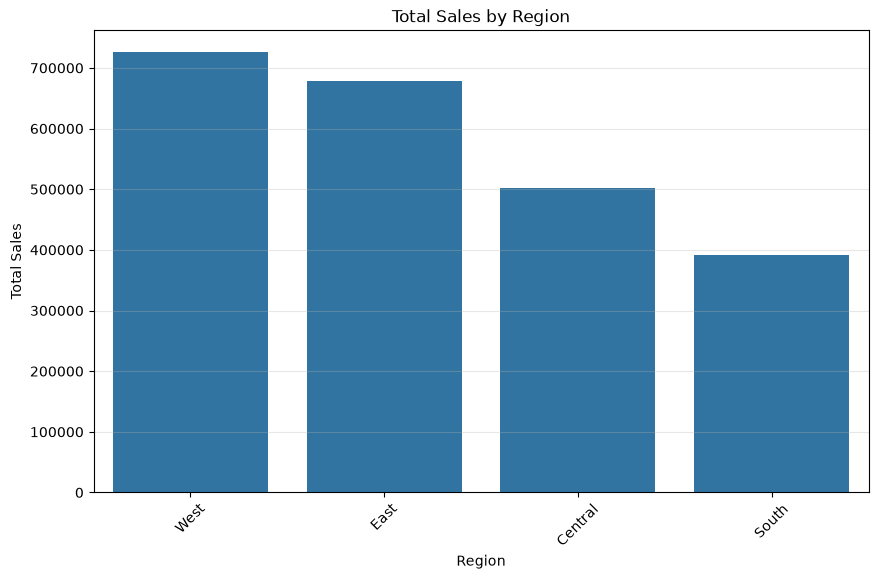

In [26]:
#Bar chart for sales by region
plt.figure(figsize=(10, 6))
plot = sns.barplot(x=sales_by_region.index, y=sales_by_region.values)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

##### The West generates the highest sales, while the South generates the lowest. Further analysis is needed to determine whether the difference is driven by customer volume, product mix, pricing, or other factors.

### Question 4: Which states generate the most revenue?

In [32]:
#Group by state
sales_by_state = df.groupby('state')['sales'].sum().sort_values(ascending=False)
print(sales_by_state.head(10))
print(sales_by_state.tail(10))

state
california      457687.6315
new york        310876.2710
texas           170188.0458
washington      138641.2700
pennsylvania    116511.9140
florida          89473.7080
illinois         80166.1010
ohio             78258.1360
michigan         76269.6140
virginia         70636.7200
Name: sales, dtype: float64
state
new mexico              4783.522
iowa                    4579.760
idaho                   4382.486
kansas                  2914.310
district of columbia    2865.020
wyoming                 1603.136
south dakota            1315.560
maine                   1270.530
west virginia           1209.824
north dakota             919.910
Name: sales, dtype: float64


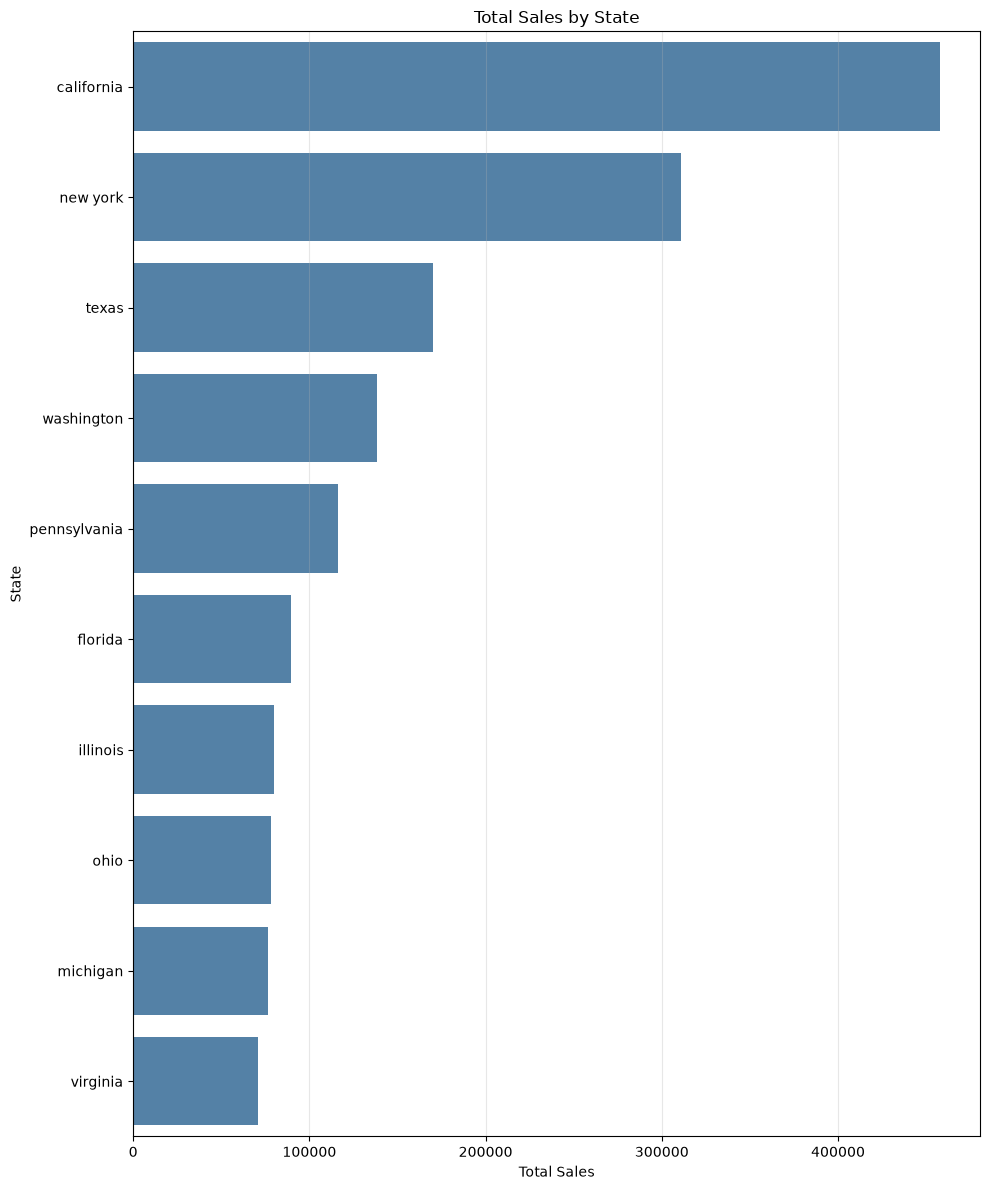

In [76]:
#Horizontal bar chart for sales by state
plt.figure(figsize=(10, 12))
sales_by_state_top10 = sales_by_state.head(10)
plot = sns.barplot(x=sales_by_state_top10.values, y=sales_by_state_top10.index, color='steelblue')
plt.title('Total Sales by State')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

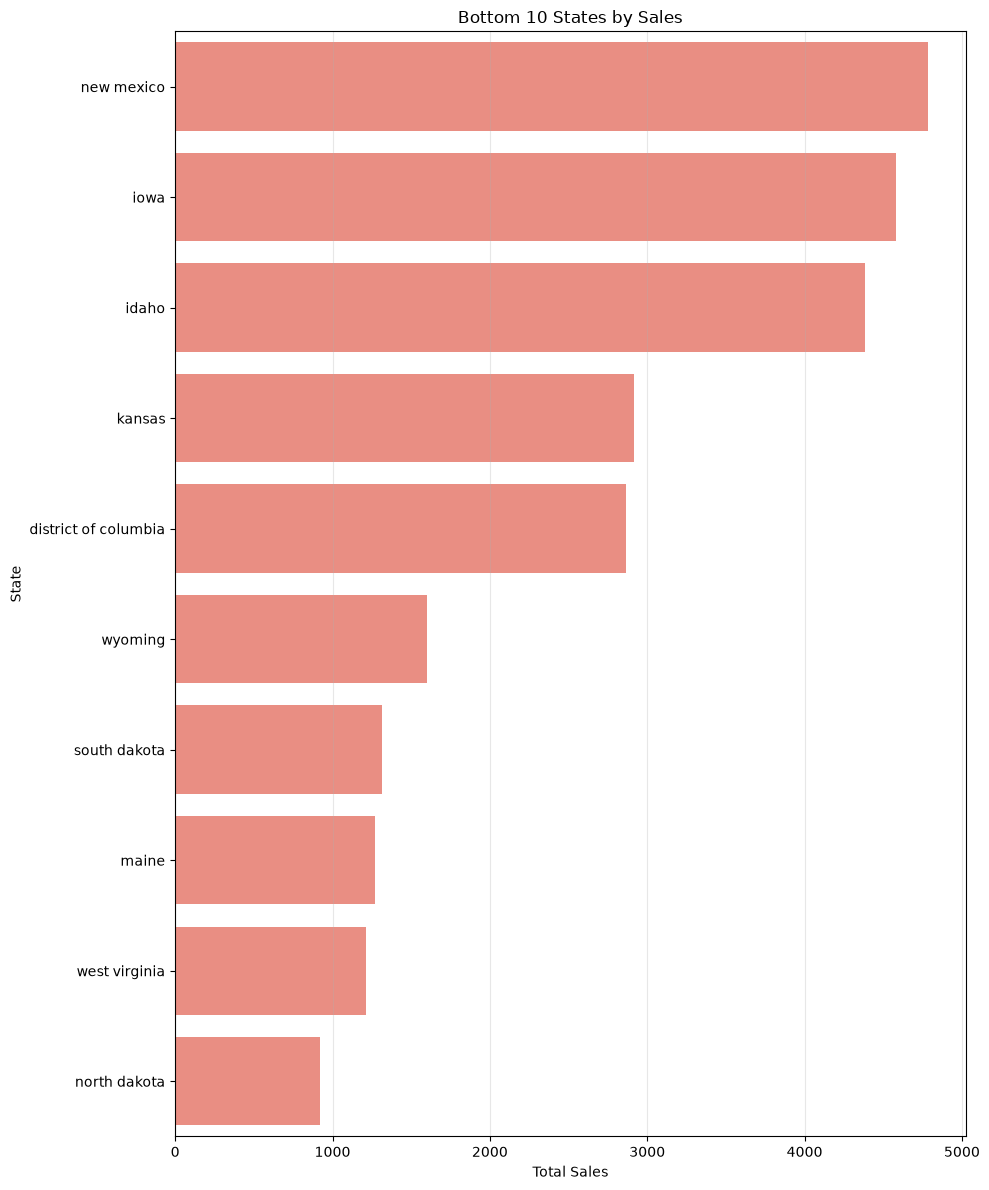

In [77]:
#bottom 10 states by sales
plt.figure(figsize=(10, 12))
plot = sns.barplot(x=sales_by_state.tail(10).values, y=sales_by_state.tail(10).index, color='salmon')
plt.title('Bottom 10 States by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##### We can see that the state with the most sales is california and with the least sales is north dakota 

### Question 5: Which customer segment generates the most revenue?

In [34]:
#Group by costumer segment
sales_by_segment = df.groupby('segment')['sales'].sum().sort_values(ascending=False)
sales_by_segment.head()

segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: sales, dtype: float64

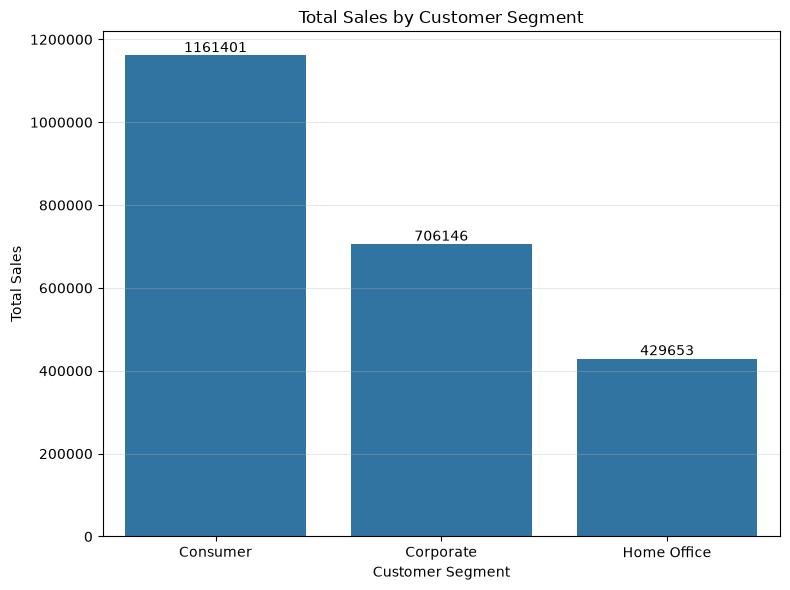

In [44]:
#Bar chart for sales by customer segment
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=sales_by_segment.index, y=sales_by_segment.values)
ax.set_title('Total Sales by Customer Segment')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Total Sales')
ax.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### Costumer segment that buy the most is consumer segment.

### Question 6: Which categories generate the highest profit?

In [71]:
#Group by categories and profit
profit_by_category = df.groupby('category')['profit'].sum().sort_values(ascending=False)
profit_by_category.head()

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

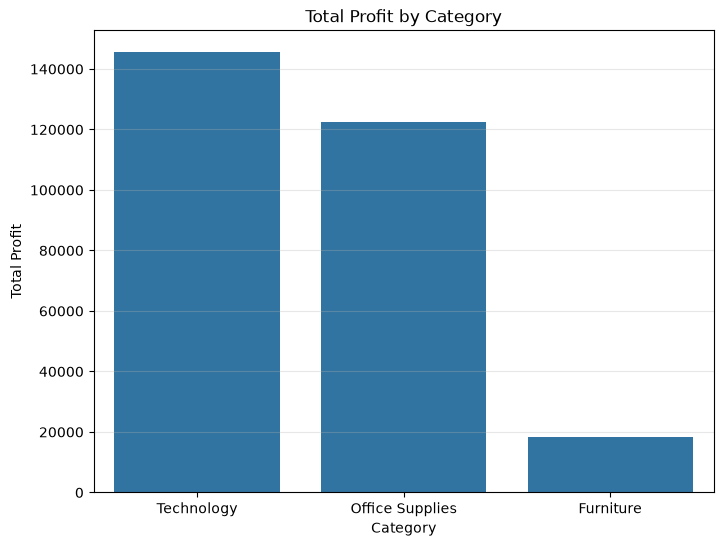

In [72]:
#Bar chart for categories and profit
plt.figure(figsize=(8, 6))
plot = sns.barplot(x=profit_by_category.index, y=profit_by_category.values)
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Technology is the category with the most profit 145454.9481. Office Supplies Category is the second with 122490.8008 and furniture are the last category with a profit of 18451.2728 

### Qestion 7: Which sub-categories lose money?

In [69]:
#Group by sub-categories and profit
profit_by_sub_category = df.groupby('sub-category')['profit'].sum().sort_values(ascending=True)
profit_by_sub_category_negative = profit_by_sub_category[profit_by_sub_category < 0]
profit_by_sub_category_negative.head()

sub-category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: profit, dtype: float64

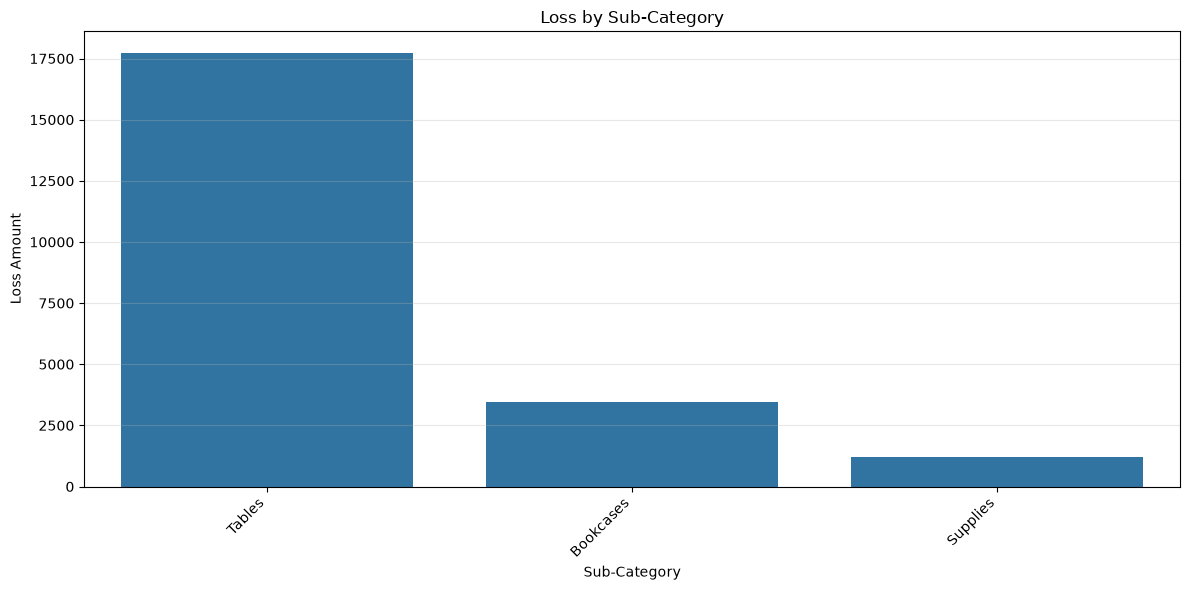

In [70]:
# bar chart for negative profit by sub-category
plt.figure(figsize=(12, 6))
sns.barplot(
    x=profit_by_sub_category_negative.index,
    y=-profit_by_sub_category_negative.values
)
plt.title('Loss by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Loss Amount')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### Sub-category with the most loss is Tables. This sub-category should be investigated further to determine the causes of its negative profitability before making a decision about discontinuing the category.


### Question 8: Does high sales always mean high profit?

Overall correlation between sales and profit: 0.4791
                       sales       profit
category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


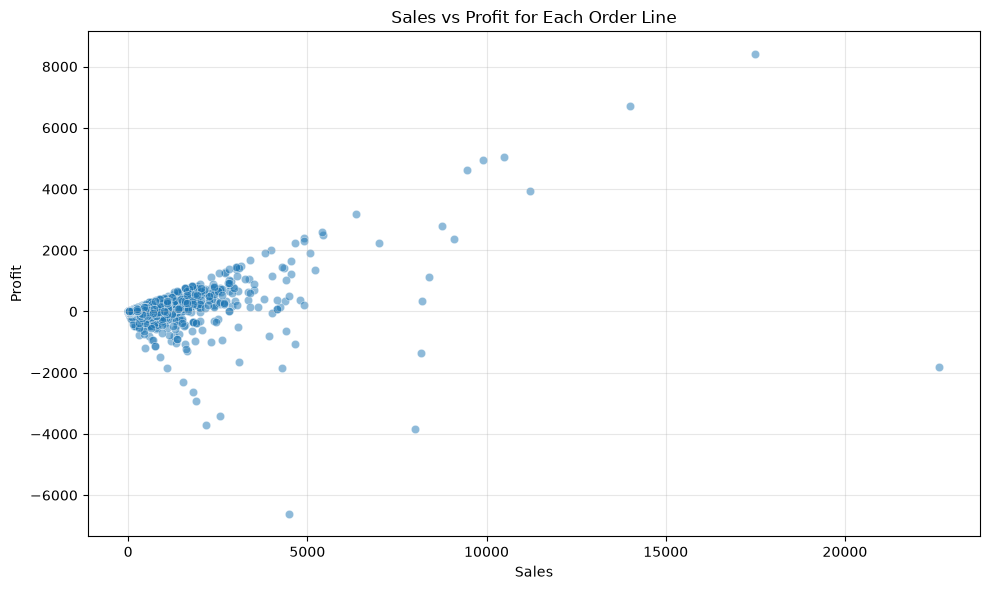

In [63]:
correlation = df['sales'].corr(df['profit'])
print(f"Overall correlation between sales and profit: {correlation:.4f}")

sales_profit_by_category = df.groupby('category')[['sales', 'profit']].sum()
print(sales_profit_by_category)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sales', y='profit', alpha=0.5)
plt.title('Sales vs Profit for Each Order Line')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### Sales and profit show a positive relationship overall, meaning higher sales tend to be associated with higher profit. However, the relationship is not perfect, and some transactions generate negative profit despite having positive sales. This suggests that revenue alone does not guarantee profitability.

### Question 9: Who are our top costumers? 

In [66]:
#Top costumer name by sales
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False)
top_customers.head(10)

customer_name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64

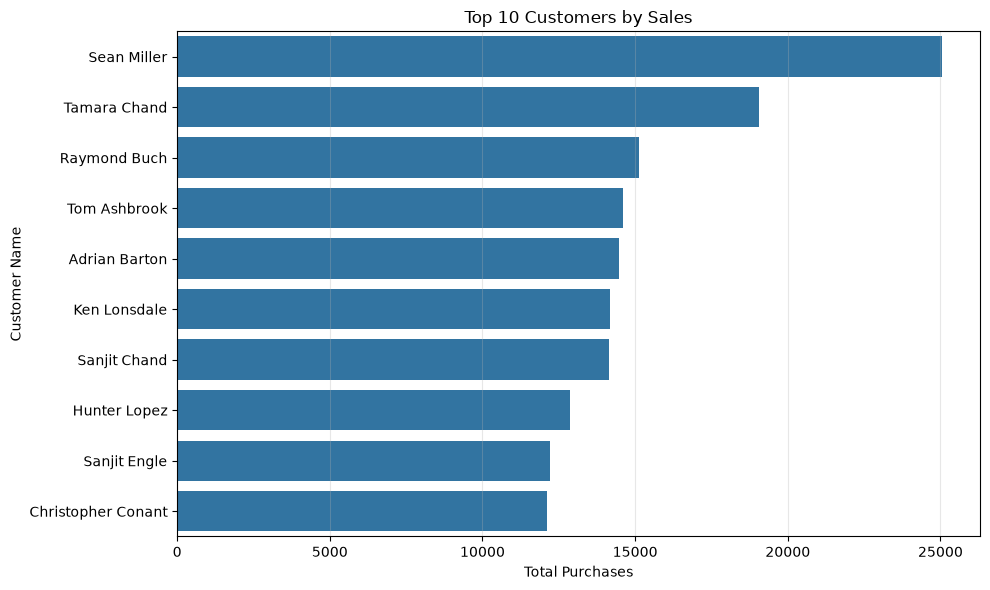

In [68]:
#Horizontal bar chart for top 10 customers by sales
plt.figure(figsize=(10, 6))
top_10_customers = top_customers.head(10)
plot = sns.barplot(x=top_10_customers.values, y=top_10_customers.index)
plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Purchases')
plt.ylabel('Customer Name')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

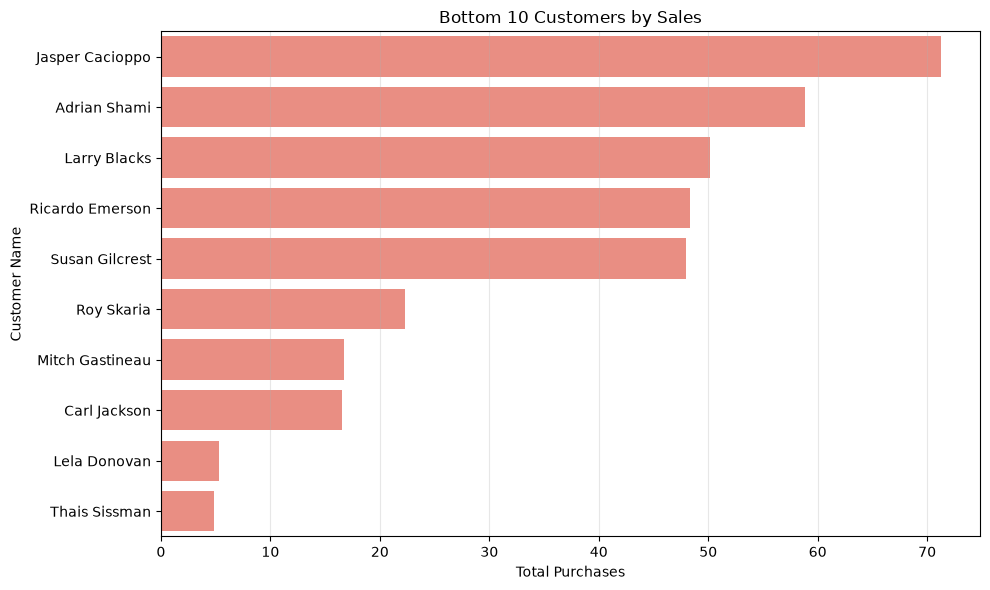

In [78]:
#horizontal bar chart for bottom 10 customers by profit
plt.figure(figsize=(10, 6))
bottom_10_customers = top_customers.tail(10)
plot = sns.barplot(x=bottom_10_customers.values, y=bottom_10_customers.index, color='salmon')
plt.title('Bottom 10 Customers by Sales')
plt.xlabel('Total Purchases')
plt.ylabel('Customer Name')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##### Our top costumer is Sean Miller by spending 25043.050

### Question 10: Who generates the most profit?

In [80]:
# customer name grouped by profit
customer_profit_grouped = df.groupby('customer_name')['profit'].sum().sort_values(ascending=False)
customer_profit_grouped.head(10)

customer_name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: profit, dtype: float64

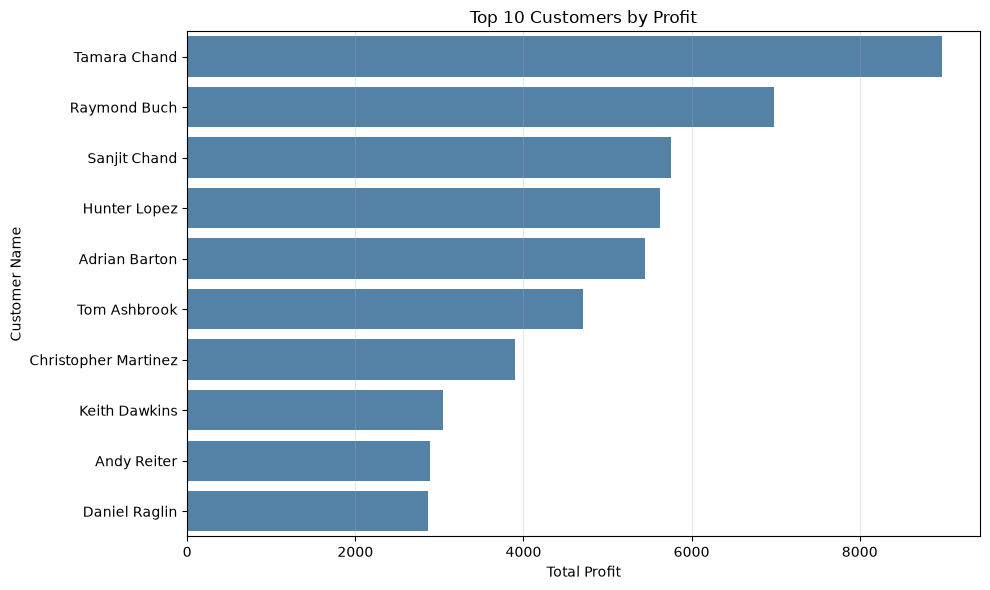

In [82]:
#Horizontal bar chart for top 10 customers by profit   
plt.figure(figsize=(10, 6))
customer_profit_top_10 = customer_profit_grouped.head(10)
plot = sns.barplot(x=customer_profit_top_10.values, y=customer_profit_top_10.index, color='steelblue')
plt.title('Top 10 Customers by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Customer Name')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##### We had our most profit from Tamara Chand with 8981.3239 profit

### Question 11: How many unique customers do we have?

In [89]:
#unique customer names
unique_customers = df['customer_name'].unique()
unique_customers_count = len(unique_customers)
print(f"Total unique customers: {unique_customers_count}")


Total unique customers: 793


##### We have 793 different costumers

### Question 12: Which customer segment is most profitable?

In [91]:
#group by customer segment and profit
profit_by_segment = df.groupby('segment')['profit'].sum().sort_values(ascending=False)
profit_by_segment.head()

segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: profit, dtype: float64

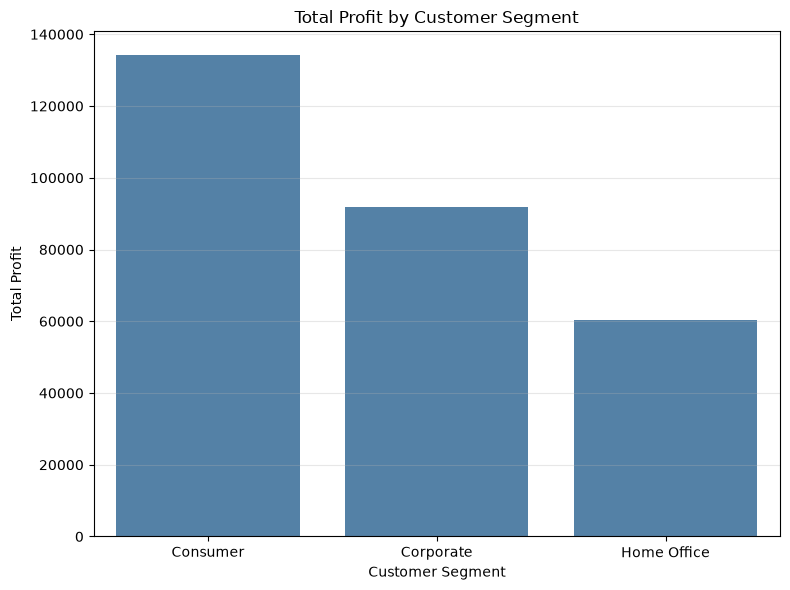

In [92]:
#Bar chart for customer segment and profit
plt.figure(figsize=(8, 6))
plot = sns.barplot(x=profit_by_segment.index, y=profit_by_segment.values, color='steelblue')
plt.title('Total Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### The most profit we are having from customer segment of consumer with 134119.2092 profit

### Question 13: Which products sell the most?

In [94]:
#group by products and sales
sales_by_product = df.groupby('product_name')['sales'].sum().sort_values(ascending=False)
sales_by_product.head()

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: sales, dtype: float64

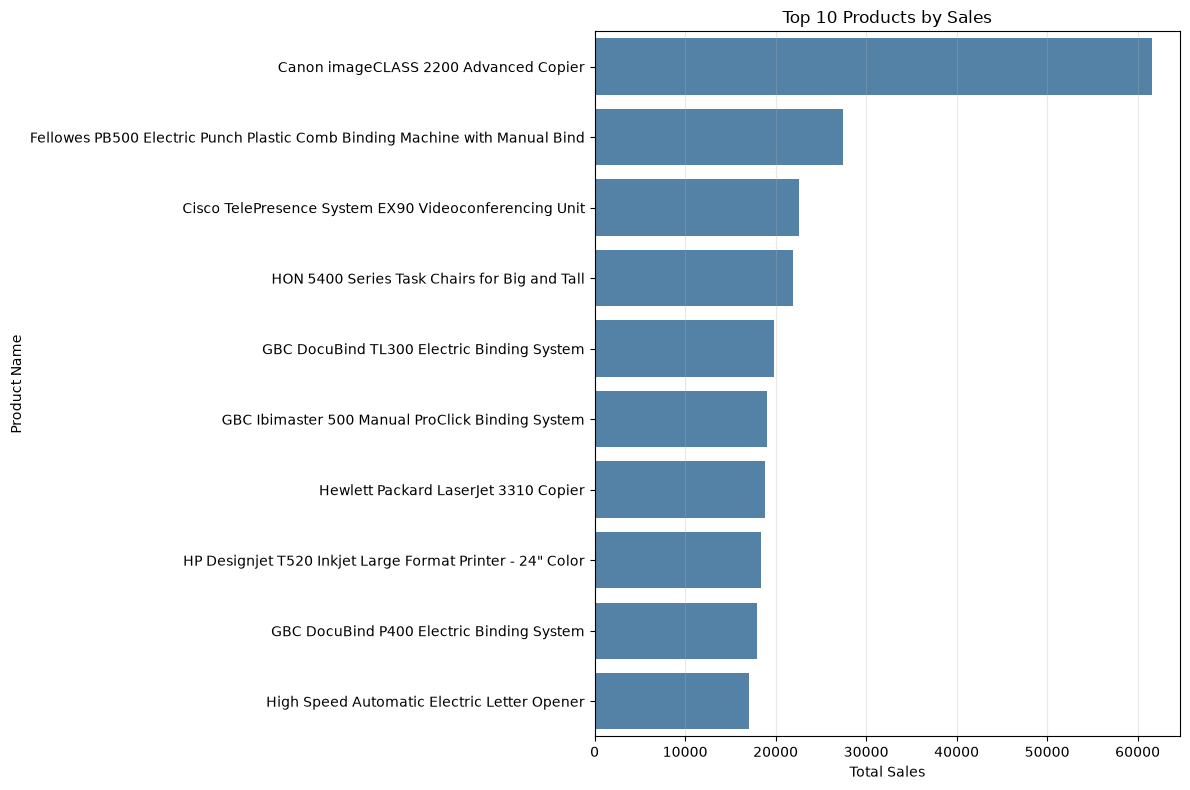

In [95]:
#Horizontal bar chart for top 10 products by sales
plt.figure(figsize=(12, 8))
sales_by_product_top_10 = sales_by_product.head(10)
plot = sns.barplot(x=sales_by_product_top_10.values, y=sales_by_product_top_10.index, color='steelblue')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##### The product that is sold the most with 61599.824 sales is Canon imageCLASS 2200 Advanced Copier.

### Question 14: Which products generate the highest profit?

In [96]:
#group by product with profit
profit_by_product = df.groupby('product_name')['profit'].sum().sort_values(ascending=False)
profit_by_product.head()

product_name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: profit, dtype: float64

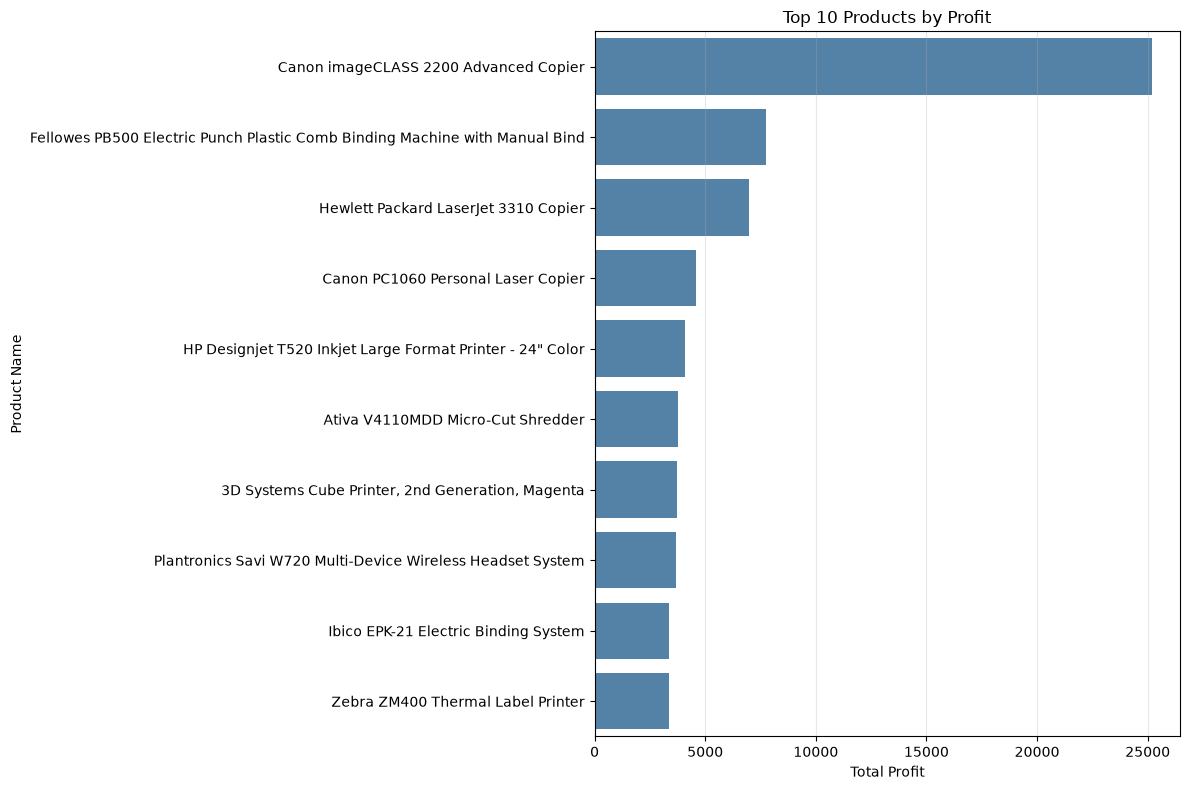

In [97]:
#Horizontal bar chart for top 10 product with the most profit
plt.figure(figsize=(12, 8))
profit_by_product_top_10 = profit_by_product.head(10)
plot = sns.barplot(x=profit_by_product_top_10.values, y=profit_by_product_top_10.index, color='steelblue')
plt.title('Top 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##### Product with the moset profit is the same as the product with the most sales, with a profit of 25199.9280 Canon imageCLASS 2200 Advanced Copier 

### Question 15: Which category contributes the most to revenue?

In [98]:
#group by category with sales
sales_by_category = df.groupby('category')['sales'].sum().sort_values(ascending=False)
sales_by_category.head()

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

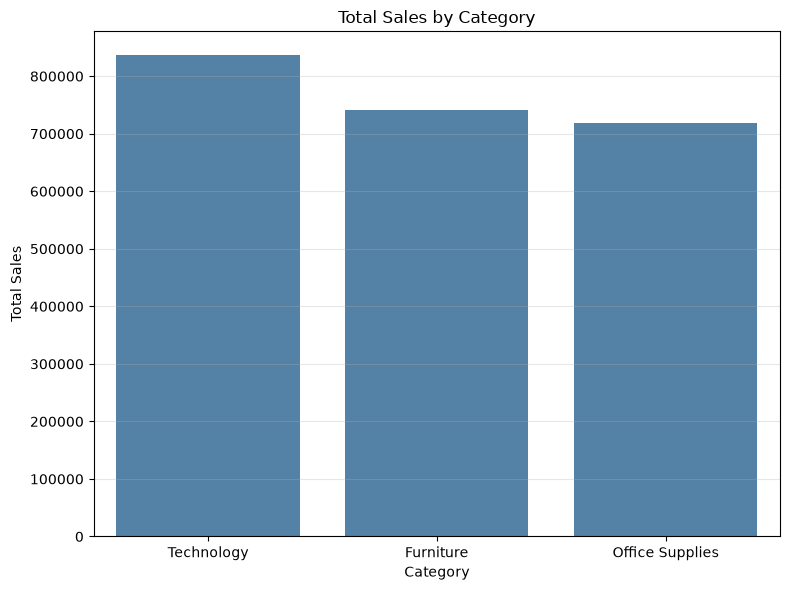

In [99]:
#Bar chart for sales by sales
plt.figure(figsize=(8, 6))
plot = sns.barplot(x=sales_by_category.index, y=sales_by_category.values, color='steelblue')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### The msot sales have happend on the category of Technolog with 836154.0330 sales

### Question 16: Which cities generate the highest revenue?

In [100]:
#Groupby city and sales
sales_by_city = df.groupby('city')['sales'].sum().sort_values(ascending=False)
sales_by_city.head()

city
new york city    256368.161
los angeles      175851.341
seattle          119540.742
san francisco    112669.092
philadelphia     109077.013
Name: sales, dtype: float64

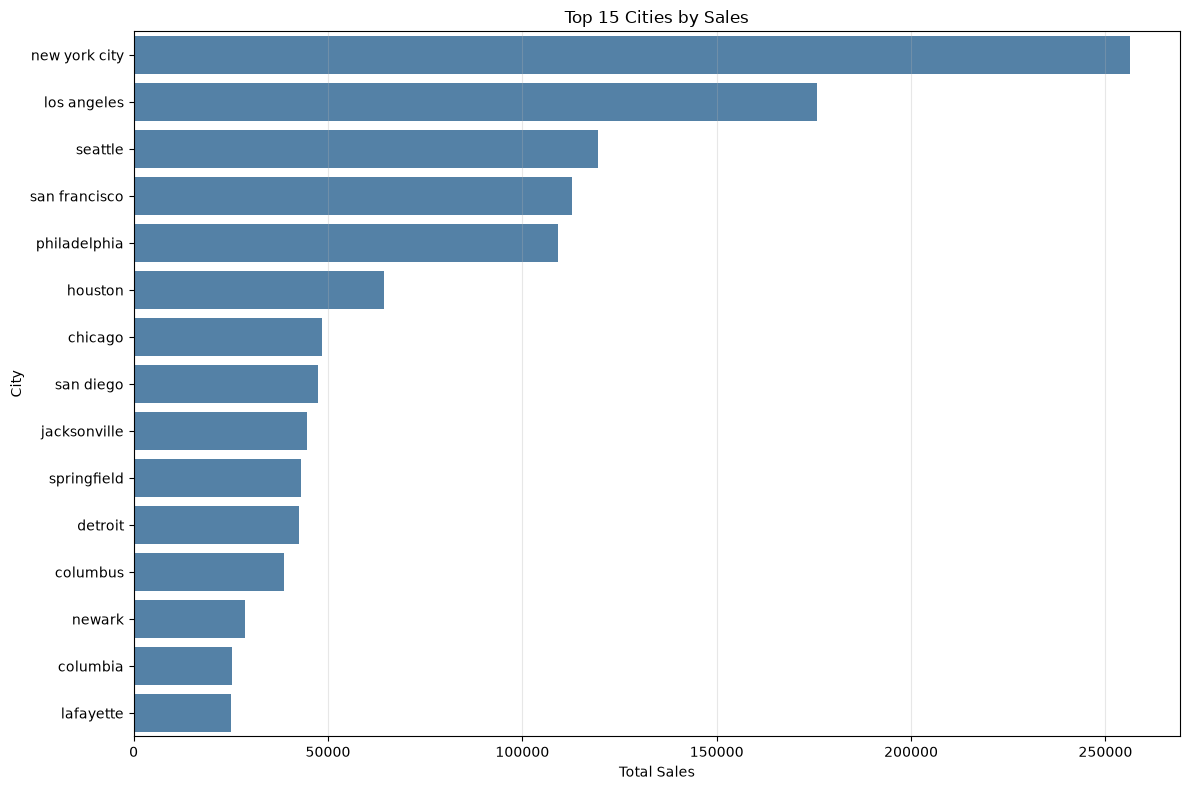

In [101]:
#Horizontal bar chart for top 15 cities by sales
plt.figure(figsize=(12, 8))
sales_by_city_top_15 = sales_by_city.head(15)
plot = sns.barplot(x=sales_by_city_top_15.values, y=sales_by_city_top_15.index, color='steelblue')
plt.title('Top 15 Cities by Sales')
plt.xlabel('Total Sales')
plt.ylabel('City')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##### New York City is the cite with the highest reveniew 256368.161

### Question 17: Which states are losing money?

In [103]:
#Groupby states and profit
profit_by_state = df.groupby('state')['profit'].sum().sort_values(ascending=Trues)
profit_by_state_negative = profit_by_state[profit_by_state < 0]
profit_by_state_negative.head()

state
texas            -25729.3563
ohio             -16971.3766
pennsylvania     -15559.9603
illinois         -12607.8870
north carolina    -7490.9122
Name: profit, dtype: float64

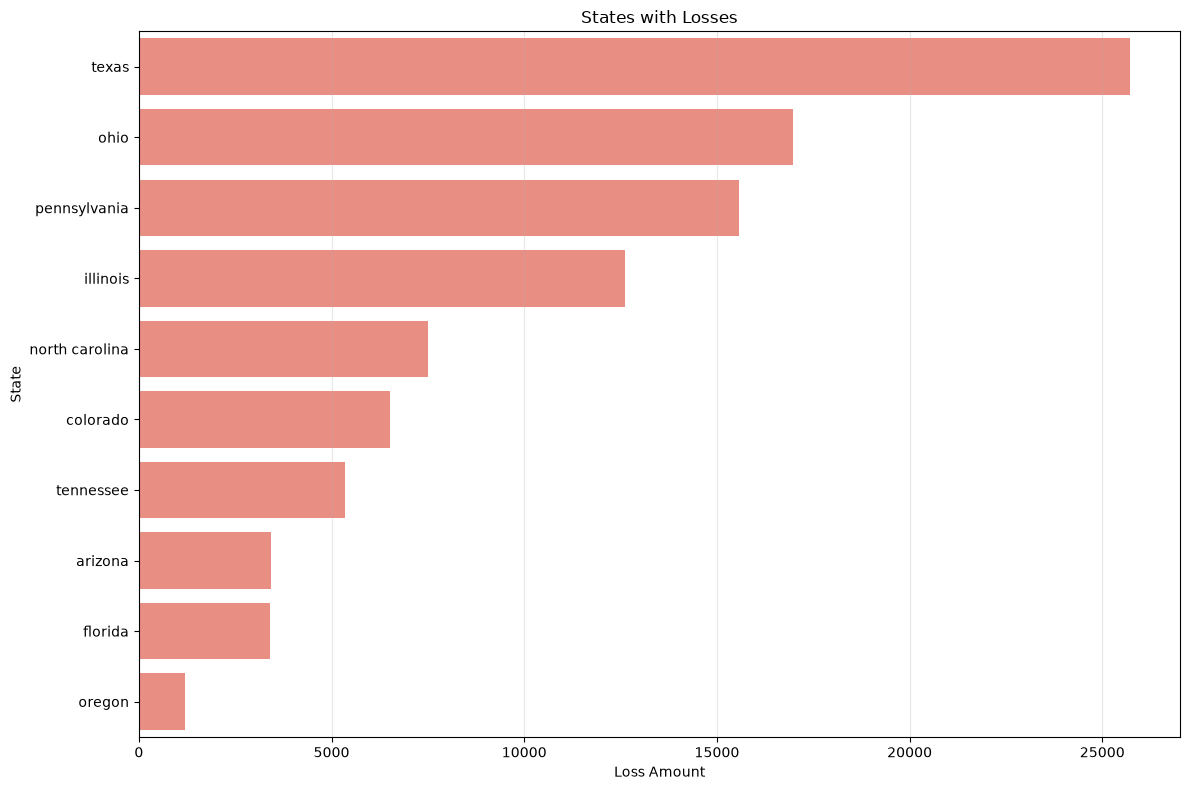

In [111]:
#Horizontal bar chart for states with losses
loss_by_state = -profit_by_state_negative

plt.figure(figsize=(12, 8))
sns.barplot(x=loss_by_state.values, y=loss_by_state.index, color='salmon')
plt.title('States with Losses')
plt.xlabel('Loss Amount')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##### Texas is the state with the most losses 25729.3563 loss.

### Question 18: Does discount reduce profit?

Correlation between discount and profit: -0.2195

Profit by Discount Level:
                mean          sum  count
discount                                
0.00       66.900292  320987.6032   4798
0.10       96.055074    9029.1770     94
0.15       27.288298    1418.9915     52
0.20       24.702572   90337.3060   3657
0.30      -45.679636  -10369.2774    227
0.32      -88.560656   -2391.1377     27
0.40     -111.927429  -23057.0504    206
0.45     -226.646464   -2493.1111     11
0.50     -310.703456  -20506.4281     66
0.60      -43.077212   -5944.6552    138
0.70      -95.874060  -40075.3569    418
0.80     -101.796797  -30539.0392    300


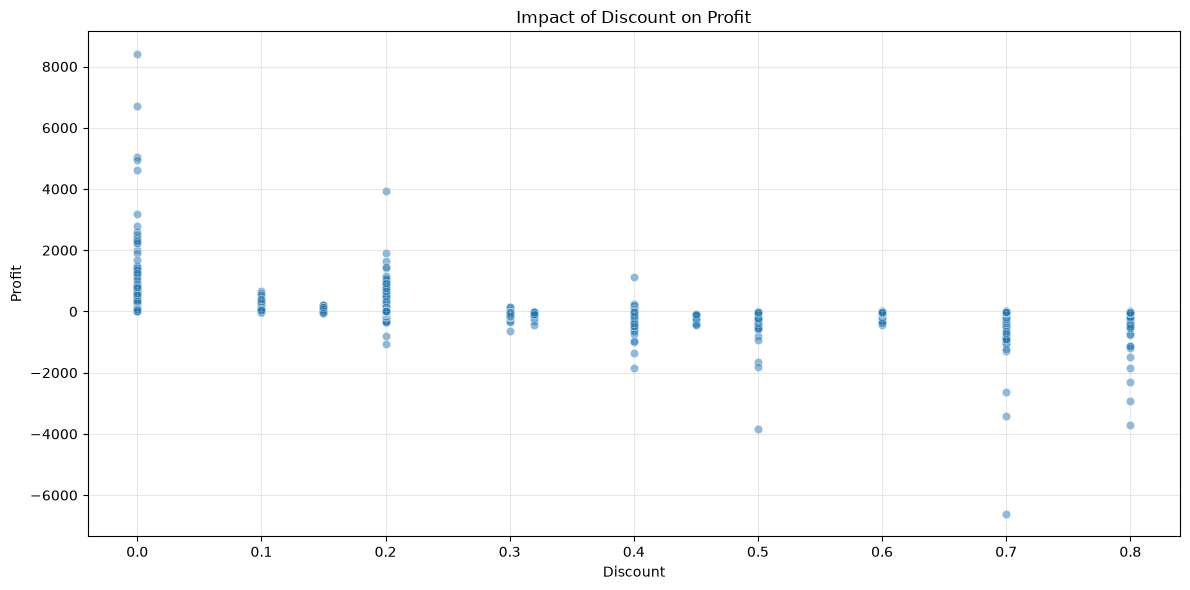

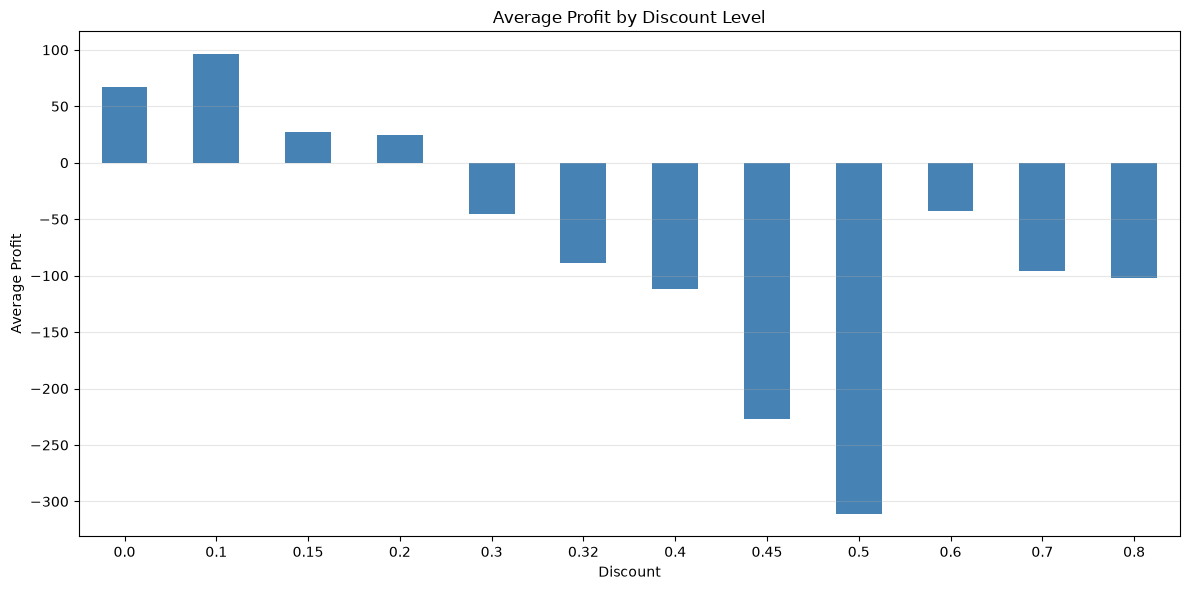

In [112]:
# Calculate correlation between discount and profit
discount_profit_correlation = df['discount'].corr(df['profit'])
print(f"Correlation between discount and profit: {discount_profit_correlation:.4f}")

# Group by discount level and calculate average profit
discount_profit = df.groupby('discount')['profit'].agg(['mean', 'sum', 'count']).sort_index()
print("\nProfit by Discount Level:")
print(discount_profit)

# Create visualization
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='discount', y='profit', alpha=0.5)
plt.title('Impact of Discount on Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bar chart showing average profit by discount level
plt.figure(figsize=(12, 6))
discount_profit['mean'].plot(kind='bar', color='steelblue')
plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### The negative correlation suggests that higher discounts are generally associated with lower profit. The data also contains several loss-making transactions at higher discount levels. However, correlation alone cannot establish that discounts directly cause the losses.

### Question 19: Which category receives the largest discounts?

In [113]:
#Groupby category and discount
discount_by_category = df.groupby('category')['discount'].mean().sort_values(ascending=False)
discount_by_category.head()

category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: discount, dtype: float64

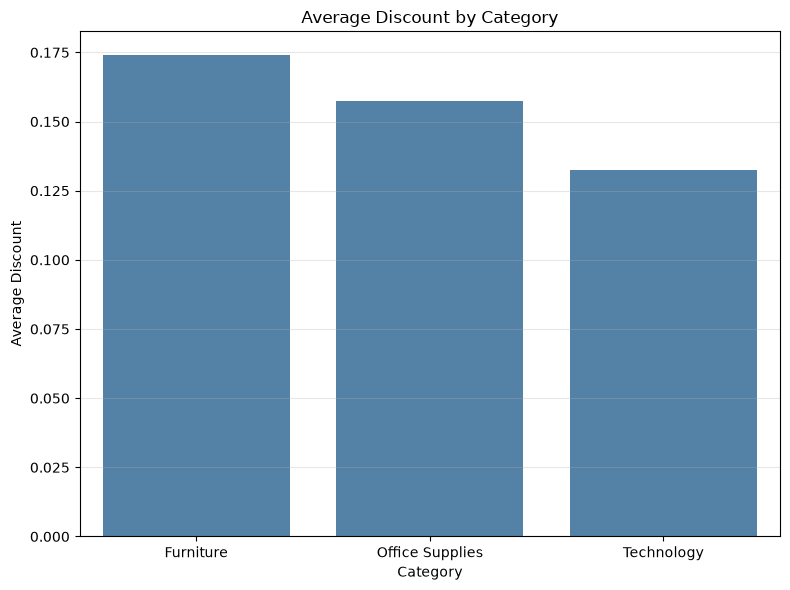

In [114]:
#Bar chart for discount by category
plt.figure(figsize=(8, 6))
plot = sns.barplot(x=discount_by_category.index, y=discount_by_category.values, color='steelblue')
plt.title('Average Discount by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### The category that recive more discount avarage is Furiniture with an mean of 0.173923 or   17.39%

### Question 20: What is the average shipping time?

In [117]:
#average shipping time
df['ship_time'].mean()

np.float64(3.958174904942966)

##### Avarage shipping time is 3.95 ~ 4 days 

### Question 21: Which region ships the slowest?

In [119]:
#Groupby region and shipping time
shipping_time_by_region = df.groupby('region')['ship_time'].mean().sort_values(ascending=True)
shipping_time_by_region.head()

region
East       3.908708
West       3.929753
South      3.958025
Central    4.058115
Name: ship_time, dtype: float64

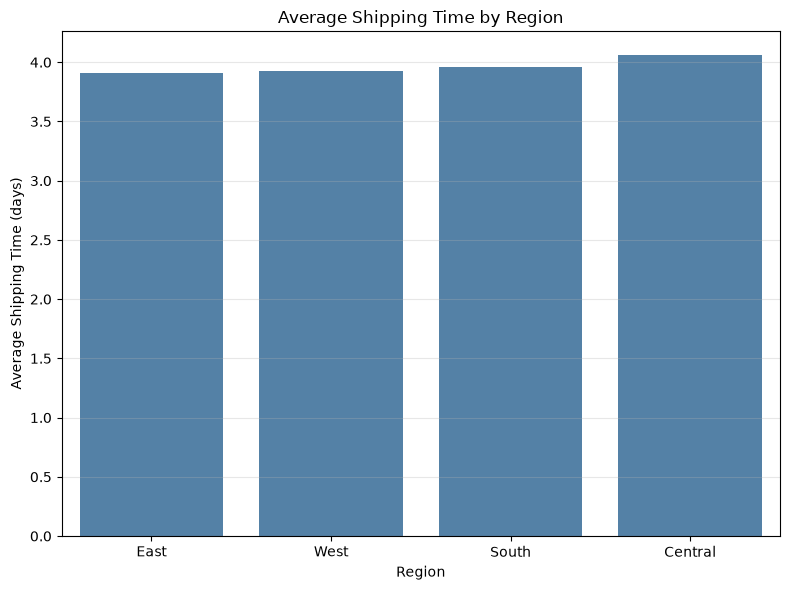

In [120]:
#Bar chart for shipping time by region
plt.figure(figsize=(8, 6))
plot = sns.barplot(x=shipping_time_by_region.index, y=shipping_time_by_region.values, color='steelblue')
plt.title('Average Shipping Time by Region')
plt.xlabel('Region')
plt.ylabel('Average Shipping Time (days)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### The region with the slowest shipping time is East region with 3.908708

### Question 22: Does longer shipping reduce profit?

In [122]:
#Groupby shipping time and profit
profit_by_shipping_time = df.groupby('ship_time')['profit'].mean().sort_values(ascending=True)
profit_by_shipping_time.head()

ship_time
1    20.436929
4    25.643394
3    26.742208
5    27.078471
6    27.660821
Name: profit, dtype: float64

Correlation between shipping time and profit: -0.0046


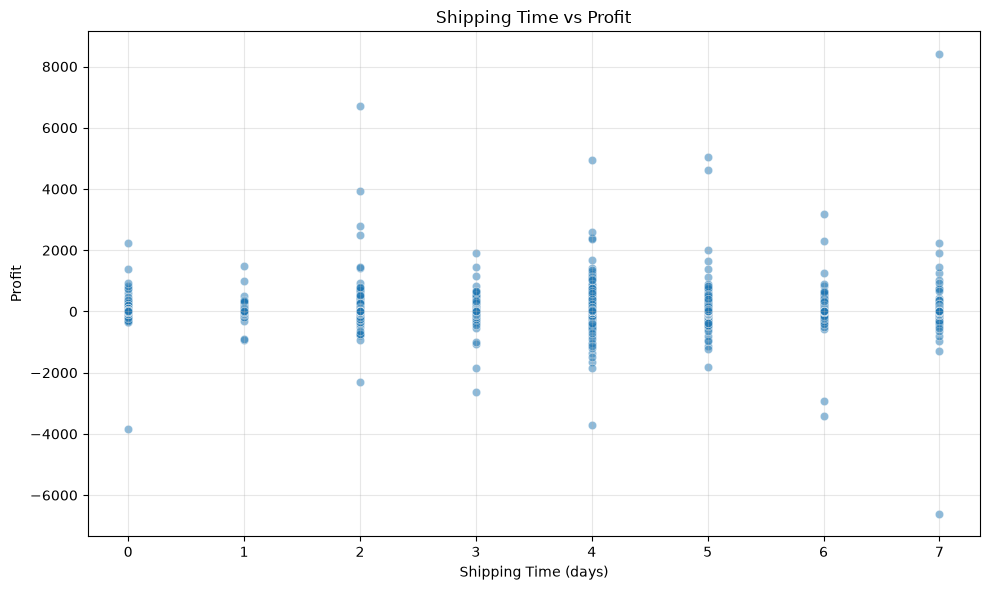

In [124]:
correlation = df['ship_time'].corr(df['profit'])
print(f"Correlation between shipping time and profit: {correlation:.4f}")

#Scatter plot for shipping time and profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ship_time', y='profit', alpha=0.5)
plt.title('Shipping Time vs Profit')
plt.xlabel('Shipping Time (days)')
plt.ylabel('Profit')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### The correlation between shipping time and profit is approximately -0.005, indicating almost no linear relationship between the two variables in this dataset. Based on this analysis, there is no meaningful evidence of a linear relationship between shipping time and profit.

### Question 23: How are numerical variables related?

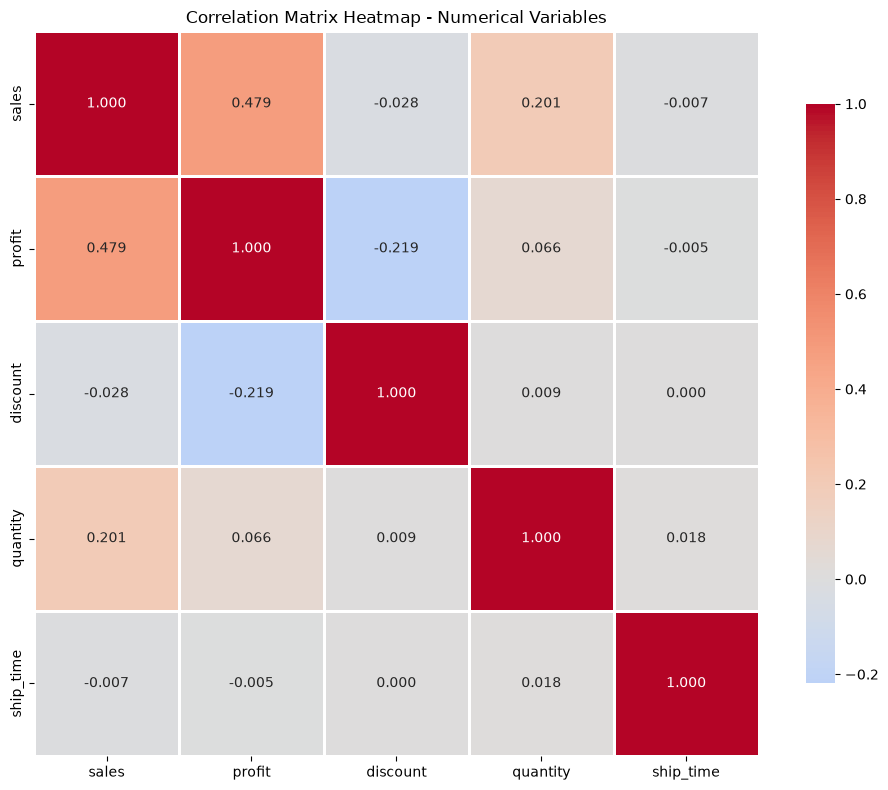

Correlation Matrix:
              sales    profit  discount  quantity  ship_time
sales      1.000000  0.479064 -0.028190  0.200795  -0.007354
profit     0.479064  1.000000 -0.219487  0.066253  -0.004649
discount  -0.028190 -0.219487  1.000000  0.008623   0.000408
quantity   0.200795  0.066253  0.008623  1.000000   0.018298
ship_time -0.007354 -0.004649  0.000408  0.018298   1.000000


In [125]:
# Create a correlation matrix for numerical variables
numerical_vars = df[['sales', 'profit', 'discount', 'quantity', 'ship_time']].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_vars, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap - Numerical Variables')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(numerical_vars)

##### Sales and profit have the strongest positive relationship among the variables analyzed. Sales and quantity also show a positive relationship, which is expected because selling more units generally increases revenue.

### Question 24: How is Sales distributed?

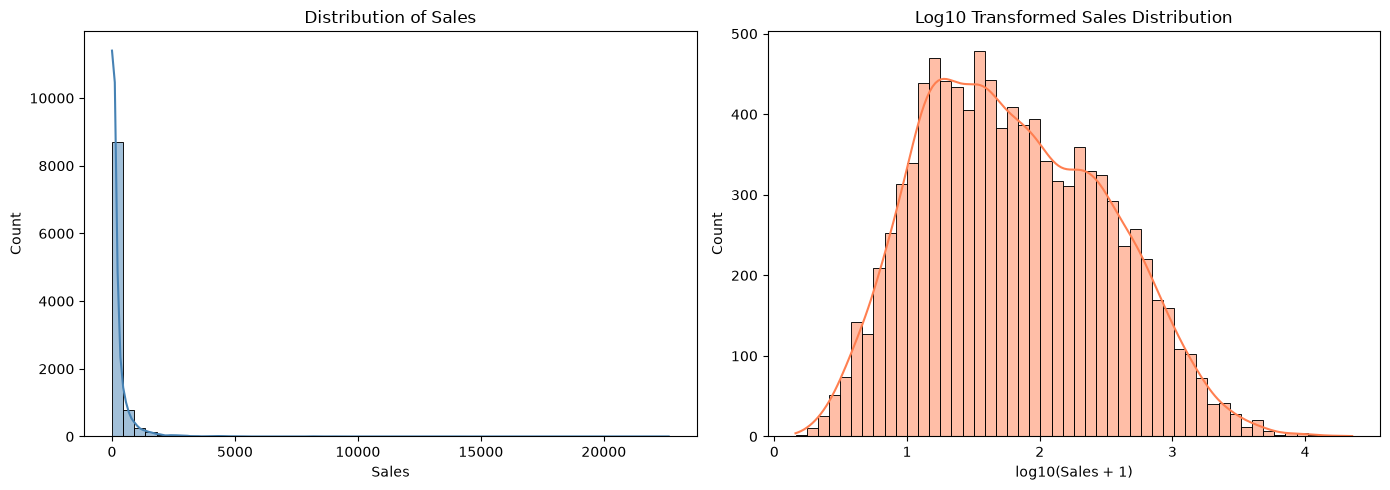

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw sales distribution
sns.histplot(df['sales'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Count')

# Log-transformed sales distribution to reduce skew
sns.histplot(np.log10(df['sales'] + 1), bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log10 Transformed Sales Distribution')
axes[1].set_xlabel('log10(Sales + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

##### Sales are strongly right-skewed. Most transactions have relatively low sales values, while a smaller number of transactions have very high sales values, creating a long right tail. The log transformation reduces the effect of these extreme values and produces a more balanced distribution.

### Question 25: How is Profit distributed?

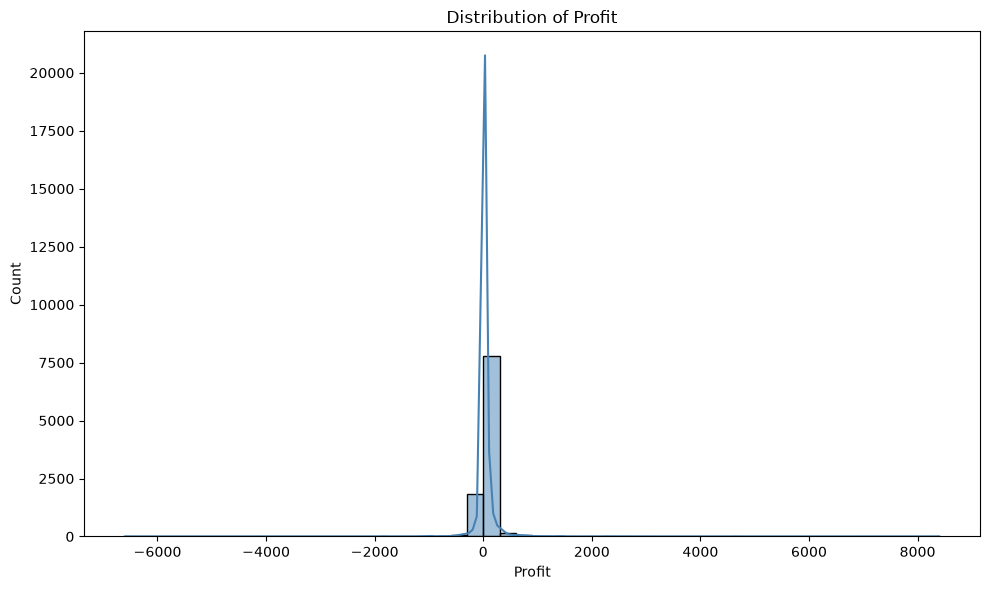

In [137]:
plt.figure(figsize=(10, 6))
sns.histplot(df['profit'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##### Profit is approximately centered around positive values but shows a noticeable right skew, with some extreme positive and negative observations.

### Question 26: Are there outliers? 

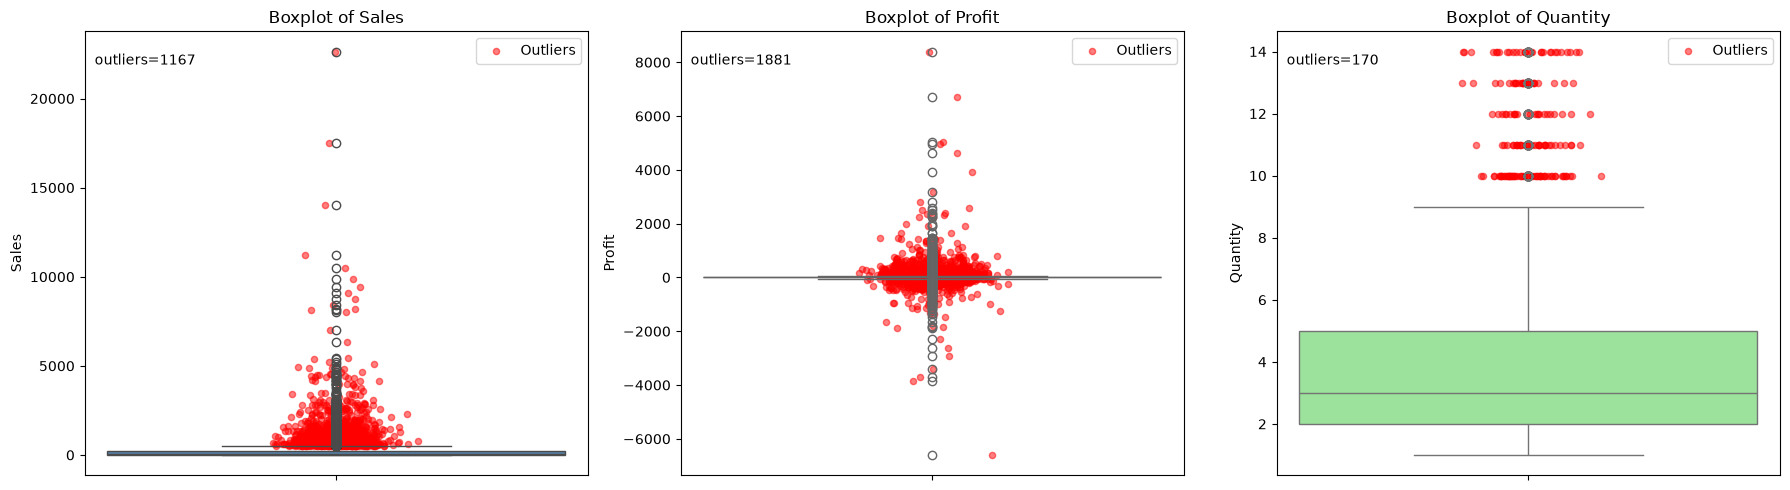

Sales outliers count: 1167
Profit outliers count: 1881
Quantity outliers count: 170


In [138]:
def find_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return column[(column < lower) | (column > upper)]

sales_outliers = find_outliers(df['sales'])
profit_outliers = find_outliers(df['profit'])
quantity_outliers = find_outliers(df['quantity'])

# Create boxplots to identify outliers in sales, profit, and quantity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, y='sales', ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot of Sales')
axes[0].set_ylabel('Sales')
axes[0].scatter(np.random.normal(0, 0.04, len(sales_outliers)), sales_outliers,
                color='red', alpha=0.5, s=20, label='Outliers')
axes[0].legend(loc='upper right')
axes[0].text(0.02, 0.95, f'outliers={len(sales_outliers)}', transform=axes[0].transAxes,
             va='top', fontsize=10)

sns.boxplot(data=df, y='profit', ax=axes[1], color='coral')
axes[1].set_title('Boxplot of Profit')
axes[1].set_ylabel('Profit')
axes[1].scatter(np.random.normal(0, 0.04, len(profit_outliers)), profit_outliers,
                color='red', alpha=0.5, s=20, label='Outliers')
axes[1].legend(loc='upper right')
axes[1].text(0.02, 0.95, f'outliers={len(profit_outliers)}', transform=axes[1].transAxes,
             va='top', fontsize=10)

sns.boxplot(data=df, y='quantity', ax=axes[2], color='lightgreen')
axes[2].set_title('Boxplot of Quantity')
axes[2].set_ylabel('Quantity')
axes[2].scatter(np.random.normal(0, 0.04, len(quantity_outliers)), quantity_outliers,
                color='red', alpha=0.5, s=20, label='Outliers')
axes[2].legend(loc='upper right')
axes[2].text(0.02, 0.95, f'outliers={len(quantity_outliers)}', transform=axes[2].transAxes,
             va='top', fontsize=10)

plt.tight_layout()
plt.show()

print('Sales outliers count:', len(sales_outliers))
print('Profit outliers count:', len(profit_outliers))
print('Quantity outliers count:', len(quantity_outliers))

##### Using the IQR method, 1,167 sales observations, 1,881 profit observations, and 170 quantity observations were identified as statistical outliers. These observations should not automatically be removed because an outlier may represent a legitimate business transaction rather than a data error. Further investigation is required to determine whether these observations are valid or problematic.